# Assignment 3

Deadline: 22.04.2026 12:00 CET

Michael Ebling, 20-930-814, michaelandreas.ebling@uzh.ch

Adrien Leforestier, 21-950-324, adrieneugenpaul.leforestier@uzh.ch

Santiago Piwonka, 25-749-060, santiago.piwonkafernandez@uzh.ch

Matias Edwardsweber, 25-748-724, matiasandres.edwardsweber@uzh.ch

James Garagnon, 25-746-595, jamespasquale.garagnon@uzh.ch

## Prerequisites: Library imports, data load and initialization of the backtest service

In [12]:
# Standard library imports
import os
import sys
import copy
from typing import Optional

# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
src_path = os.path.join(project_root, 'qpmwp-course/src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    # load_pickle,
    load_data_spi,
)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization_data import OptimizationData
from optimization.optimization import (
    Optimization,
    Objective,
    MeanVariance,
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest



In [13]:
PATH_TO_DATA = os.path.join(project_root, 'qpmwp-course/data/')     # <CHANGE THIS TO YOUR PATH TO DATA>

In [14]:

# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}jkp_data.parquet')


# -------------------------
# First, ensure that market data and jkp data 
# have the same dates by forward filling the market data for the missing dates.
# -------------------------

market_data_dates = (
    market_data
    .index.get_level_values('date')
    .unique().sort_values()
)
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)

# Find the jkp_data_dates which are not in the market_data_dates
missing_dates = jkp_data_dates[~jkp_data_dates.isin(market_data_dates)]

# Extend the market data for the missing dates using the last available market data (i.e., forward fill).
tmp_dict = {}
for date in missing_dates:
    last_date = market_data_dates[market_data_dates <= date][-1]
    tmp_dict[date] = market_data.loc[last_date]
    
df_missing = pd.concat(tmp_dict, axis=0)
df_missing.index.names = market_data.index.names
market_data_ffill = pd.concat([market_data, df_missing]).sort_index()


# -------------------------
# Define rebalancing dates
# -------------------------

n_month = 3 # We want to rebalance every n_month months

# We want to use the dates from the jkp data for rebalancing, 
# since they are less frequent than the market data dates.
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data_dates[0]
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
# Drop the first rebalancing dates which are before 2002-01-01, 
# because of poor data coverage.
rebdates = [date for date in rebdates if date > '2002-01-01']


# -------------------------
# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
# -------------------------

data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = load_data_spi(path='../data/')

In [15]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365 * 3,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365 * 3,
        min_volume=500_000,
        agg_fn=np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [16]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            **kwargs,
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        self._covmat = self.covariance.estimate(X=X, inplace=False)
        self._mu = self.expected_return.estimate(X=X, inplace=False)
        self.objective = Objective(
            q=np.asarray(self._mu) * -1,
            P=np.asarray(self._covmat) * 2,
        )
        return None

    def solve(self) -> None:
        max_iter = self.params.get('max_iter', 10)
        covmat_np = np.asarray(self._covmat)
        mu_np = np.asarray(self._mu)

        risk_aversion = 1.0

        for _ in range(max_iter):
            self.objective = Objective(
                P=covmat_np * 2 * risk_aversion,
                q=mu_np * -1,
            )
            super().solve()

            weights = self.results.get('weights', {})
            w = np.array(list(weights.values()))

            sigma_p_sq = float(w @ covmat_np @ w)
            mu_p = float(mu_np @ w)

            if sigma_p_sq < 1e-12 or mu_p <= 0:
                break

            risk_aversion_new = mu_p / sigma_p_sq
            if abs(risk_aversion_new - risk_aversion) < 1e-6:
                break
            risk_aversion = risk_aversion_new

        self.params['risk_aversion'] = risk_aversion
        return None

b) 

(2 points)

Provide either a theoretical or an empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

In [17]:
# bs.optimization = MaxSharpe(
#     covariance=Covariance(method='pearson'),
#     expected_return=ExpectedReturn(method='geometric'),
#     solver_name='cvxopt',  # <change this to your preferred solver>
#     # <optionally add any other arguments you may need, e.g., number of iterations, tolerance, etc.>
# )
# bs.prepare_rebalancing(rebdates[-1])
# bs.optimization.set_objective(bs.optimization_data)
# bs.optimization.solve()

# bs.optimization.results

# Empirical convergence check: solve for a single date and track Sharpe per iteration.

class MaxSharpeVerbose(MaxSharpe):

    def solve(self) -> None:
        max_iter = self.params.get('max_iter', 10)
        covmat_np = np.asarray(self._covmat)
        mu_np = np.asarray(self._mu)
        risk_aversion = 1.0

        for i in range(max_iter):
            self.objective = Objective(
                P=covmat_np * 2 * risk_aversion,
                q=mu_np * -1,
            )
            super(MaxSharpe, self).solve()

            weights = self.results.get('weights', {})
            w = np.array(list(weights.values()))

            sigma_p_sq = float(w @ covmat_np @ w)
            mu_p = float(mu_np @ w)
            sharpe = mu_p / np.sqrt(sigma_p_sq) if sigma_p_sq > 1e-12 else 0

            print(f"  Iter {i+1:2d}: lambda={risk_aversion:.6f}, "
                  f"mu_p={mu_p:.6f}, sigma_p={np.sqrt(sigma_p_sq):.6f}, Sharpe={sharpe:.6f}")

            if sigma_p_sq < 1e-12 or mu_p <= 0:
                break

            risk_aversion_new = mu_p / sigma_p_sq
            if abs(risk_aversion_new - risk_aversion) < 1e-6:
                print("  Converged.")
                break
            risk_aversion = risk_aversion_new

        self.params['risk_aversion'] = risk_aversion


bs.optimization = MaxSharpeVerbose(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
)
bs.prepare_rebalancing(rebdates[-1])
bs.optimization.set_objective(bs.optimization_data)
bs.optimization.solve()

  Iter  1: lambda=1.000000, mu_p=0.000783, sigma_p=0.012955, Sharpe=0.060424
  Iter  2: lambda=4.664202, mu_p=0.000561, sigma_p=0.009107, Sharpe=0.061625
  Iter  3: lambda=6.766871, mu_p=0.000501, sigma_p=0.008482, Sharpe=0.059029
  Iter  4: lambda=6.959062, mu_p=0.000496, sigma_p=0.008446, Sharpe=0.058779
  Iter  5: lambda=6.959190, mu_p=0.000496, sigma_p=0.008446, Sharpe=0.058779
  Converged.


## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

The code below runs a backtest of a MaxSharpe portfolio that includes a turnover penalty. The optimization problem is

$$
\arg\min_{w}\;\Bigl(-\mu^\top w \;+\; \frac{\lambda}{2}\, w^\top \Sigma w \;+\; \tau |w - w^{0}|\Bigr),
$$

where $\mu$ is the vector of expected returns, $\Sigma$ the covariance matrix, and $w^{0}$ the initial portfolio weights.
The parameter $\lambda$ is the risk‑aversion coefficient calibrated in Question 1.a, and $\tau$ is the turnover penalty parameter to be calibrated here.

Your task is to choose a value for the turnover penalty such that the MaxSharpe backtest exhibits an annual turnover of approximately 100\%.

**Hint:** run the backtest for only a few rebalancing dates, compute the resulting turnover using method `bt_ms.turnover`, and iteratively adjust the turnover penalty until the target turnover is reached.


In [18]:
turnover_penalty = 0.1   # calibrated value

# Update the backtest service with a MaxSharpe optimization object
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',     # optionally, change this to your preferred solver
    turnover_penalty=None,    # <your code here>
)

# Instantiate the backtest object
bt_ms = Backtest()

# Run the backtest
bt_ms.run(bs=bs)

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

## 4. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% per annum (p.a.) and variable costs of 0.3% p.a.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


In [19]:
fixed_costs = 0.0 # <your code here> 
variable_costs = 0.0 # <your code here>
return_series = bs.data.get_return_series(weekdays_only=False)

sim_ms = bt_ms.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

sim = pd.concat({
    'bm': bs.data.bm_series,
    'ms': sim_ms,
}, axis = 1).dropna()

# Plot the cumulative returns of the strategy and the benchmark
import matplotlib.pyplot as plt

fixed_costs = 0.01     # 1% p.a.
variable_costs = 0.003 # 0.3% p.a.
return_series = bs.data.get_return_series(weekdays_only=False)

sim_ms = bt_ms.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

sim = pd.concat({
    'bm': bs.data.bm_series,
    'ms': sim_ms,
}, axis=1).dropna()

cum_ret = (1 + sim).cumprod()
fig, ax = plt.subplots(figsize=(12, 6))
cum_ret['ms'].plot(ax=ax, label='MaxSharpe', color='steelblue')
cum_ret['bm'].plot(ax=ax, label='SPI Index', color='darkorange', linestyle='--')
ax.set_title('Cumulative Returns: MaxSharpe vs SPI Index')
ax.set_ylabel('Cumulative Return (rebased to 1)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


KeyError: 0

<Axes: title={'center': 'Turnover'}>

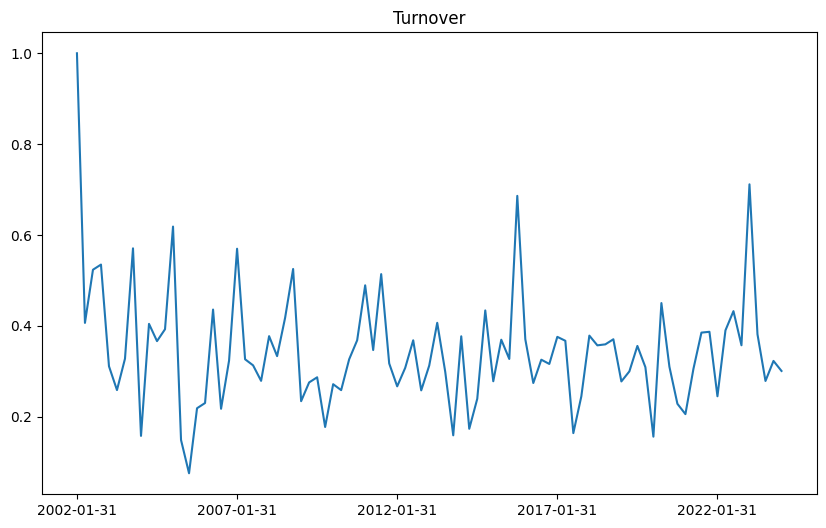

In [ ]:
# Turnover
to_ms = bt_ms.strategy.turnover(return_series=return_series)
to_ms.plot(title='Turnover', figsize = (10, 6))

In [ ]:

# Annualized turnover per annum (pa) in percentage
rebdates_per_year = 12 / n_month
to_pa = round(to_ms.iloc[1:].mean() * rebdates_per_year * 100, 2)
print(f"The annualized turnover is: {to_pa}%")

The annualized turnover is: 135.35%


In [ ]:
# Decriptive statistics

def descriptive_stats(returns: pd.DataFrame, n_days: int = 252) -> pd.DataFrame:
    stats = {}
    for col in returns.columns:
        r = returns[col].dropna()
        T = len(r)

        ann_return = (1 + r).prod() ** (n_days / T) - 1
        ann_vol    = r.std() * np.sqrt(n_days)
        sharpe     = ann_return / ann_vol if ann_vol > 0 else np.nan

        cum     = (1 + r).cumprod()
        max_dd  = (cum / cum.cummax() - 1).min()
        calmar  = ann_return / abs(max_dd) if max_dd < 0 else np.nan

        downside = r[r < 0].std() * np.sqrt(n_days)
        sortino  = ann_return / downside if downside > 0 else np.nan

        stats[col] = {
            'Ann. Return (%)':     round(ann_return * 100, 2),
            'Ann. Volatility (%)': round(ann_vol * 100, 2),
            'Sharpe Ratio':        round(sharpe, 3),
            'Max Drawdown (%)':    round(max_dd * 100, 2),
            'Calmar Ratio':        round(calmar, 3),
            'Sortino Ratio':       round(sortino, 3),
            'Skewness':            round(r.skew(), 3),
            'Excess Kurtosis':     round(r.kurtosis(), 3),
        }

    return pd.DataFrame(stats)

desc = descriptive_stats(sim)
desc

,bm,ms
Ann. Return (%),5.560,6.490
Ann. Volatility (%),16.470,12.320
Sharpe Ratio,0.338,0.527
Max Drawdown (%),-53.250,-47.860
Calmar Ratio,0.104,0.136
Sortino Ratio,0.428,0.643
Skewness,-0.192,-0.490
Excess Kurtosis,8.421,6.897
